In [19]:
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from typing import TypedDict

In [20]:
load_dotenv()

True

In [21]:
class LLMState(TypedDict):
    question: str
    answer: str

In [22]:
def question_answer(state: LLMState) -> LLMState:
    llm = ChatOpenAI(model="gpt-3.5-turbo")

    prompt = f"Answer the following question: {state['question']}"

    response = llm.invoke(prompt)

    state["answer"] = response.content

    return state

In [23]:
graph = StateGraph(LLMState)

graph.add_node('question_answer', question_answer)

graph.add_edge(START, 'question_answer')
graph.add_edge('question_answer', END)

workflow = graph.compile()

In [24]:
input_state = {"question": "What is the capital of France?"}

final_state = workflow.invoke(input_state)

print(final_state)

{'question': 'What is the capital of France?', 'answer': 'The capital of France is Paris.'}


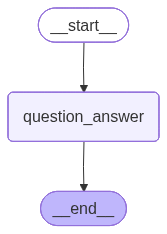

In [25]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())